In [20]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import scipy.stats as stats
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
import time
from datetime import datetime
import os
import subprocess

pd.set_option('display.max_columns', None)

In [4]:
goodreads_export = f'./data/goodreads_library_export.csv'

if os.path.isfile(goodreads_export):
    os.remove(goodreads_export)
# Export my books
options = Options()
options.add_experimental_option("prefs", {
"download.default_directory": r"C:\Users\Alex\Documents\testing\goodreads-ranker\data",
"download.prompt_for_download": False,
"download.directory_upgrade": True,
"safebrowsing.enabled": True
})

driver = webdriver.Chrome(options=options)
driver.get('https://www.goodreads.com/ap/signin?language=en_US&openid.assoc_handle=amzn_goodreads_web_na&openid.claimed_id=http%3A%2F%2Fspecs.openid.net%2Fauth%2F2.0%2Fidentifier_select&openid.identity=http%3A%2F%2Fspecs.openid.net%2Fauth%2F2.0%2Fidentifier_select&openid.mode=checkid_setup&openid.ns=http%3A%2F%2Fspecs.openid.net%2Fauth%2F2.0&openid.pape.max_auth_age=0&openid.return_to=https%3A%2F%2Fwww.goodreads.com%2Fap-handler%2Fsign-in')

username_field = driver.find_element(By.NAME, 'email')
password_field = driver.find_element(By.NAME, 'password')
username_field.send_keys('alejandro.shutov@gmail.com')
password_field.send_keys('Alejo26alejo26')
password_field.send_keys(Keys.RETURN)

WebDriverWait(driver, 10).until(EC.presence_of_element_located((By.CLASS_NAME, "homePrimaryColumn")))
driver.get('https://www.goodreads.com/review/import')
time.sleep(2)

goodreads_current_date = datetime.now().strftime('%m/%d/%Y')
file = driver.find_element(By.CLASS_NAME, 'fileList')
if goodreads_current_date not in file.text:
    export_button = driver.find_element(By.CLASS_NAME, 'js-LibraryExport')
    export_button.click()

WebDriverWait(driver, 60).until(EC.presence_of_element_located((By.CLASS_NAME, "fileList")))

while True:
    file = driver.find_element(By.CLASS_NAME, 'fileList')
    if goodreads_current_date in file.text:
        # find the link and click it
        link = file.find_element(By.TAG_NAME, 'a')
        link.click()
        time.sleep(1)
        break
    else:
        time.sleep(5)

driver.quit()

In [5]:
df1 = pd.read_csv(goodreads_export)
df1['Original Publication Year'] = df1['Original Publication Year'].fillna(df1['Year Published'])

df1 = df1.drop(['Author l-f', 'Additional Authors', 'ISBN', 'ISBN13', 'Binding', 'My Review', 'Date Read', 'Date Added', 'Bookshelves with positions', 'Bookshelves', 'Exclusive Shelf', 'Spoiler', 'Private Notes', 'Year Published', 'Read Count', 'Owned Copies'], axis=1)

with open(f'./data/book_ids.txt', 'w', encoding='utf-8') as f:
    for index, row in df1.iterrows():
        f.write(f'{row["Book Id"]}\n')

In [34]:
!python get_books.py --book_ids_path .\data\ --output_directory_path .\data\

510
3
2024-04-21 17:51:32.477184 get_books.py: Scraping 32839245...
2024-04-21 17:51:32.477184 get_books.py: #1 out of 513 books
============================= Skipping book 32839245 because the script tag was not found.
2024-04-21 17:51:33.176216 get_books.py: Scraping 17869520...
2024-04-21 17:51:33.176216 get_books.py: #2 out of 513 books
============================= Skipping book 17869520 because the script tag was not found.
2024-04-21 17:51:33.924641 get_books.py: Scraping 48579471...
2024-04-21 17:51:33.924641 get_books.py: #3 out of 513 books
============================= Skipping book 48579471 because the script tag was not found.
2024-04-21 17:51:34.727401 get_books.py:

🎉 Success! All book metadata scraped. 🎉

Metadata files have been output to /.\data\
Goodreads scraping run time = ⏰ 0:00:02.270523 ⏰


### Once you have scraped for more info

In [35]:
current_month = datetime.now().strftime('%m-%Y')
df2 = pd.read_csv(f'./data/{current_month}_goodreads_scraped.csv')
df = df1.merge(df2, left_on='Book Id', right_on='book_id', how='inner')
df = df.drop(['Book Id', 'Title', 'average_rating'], axis=1)
df = df.rename(columns={'Author': 'author', 'Number of Pages': 'num_pages', 'Original Publication Year': 'year', 'My Rating': 'my_rating', 'Publisher': 'publisher', 'Average Rating': 'average_rating'})

df.rating_distribution = df.rating_distribution.apply(eval)
df.genres = df.genres.apply(eval)
df['age'] = int(datetime.now().strftime('%Y')) - df.year
median_age = df.age.median()
df.age = df.age.fillna(median_age)
median_num_pages = df.num_pages.median()
df.num_pages = df.num_pages.fillna(median_num_pages)
df.my_rating = df.my_rating.replace(0, np.nan)

def normalize_dict(d):
    max_value = max(d.values())
    return {f'num_{k}star_rating': v / max_value for k, v in d.items()}

df = pd.concat([df, df['rating_distribution'].apply(normalize_dict).apply(pd.Series)], axis=1)

# Elaborate rating distribution

### Normalize ratings

In [36]:
def fit_quadratic(row):
    x = np.array([1, 2, 3, 4, 5])
    a, b, c = np.polyfit(x, row, 2)
    return pd.Series([2*a, b, c])

# Apply the function to each row
coefficients = df[['num_1star_rating','num_2star_rating','num_3star_rating','num_4star_rating','num_5star_rating']].apply(fit_quadratic, axis=1)

# Create the new columns from the result
df['2a'], df['b'], df['c'] = coefficients[0], coefficients[1], coefficients[2]

scaler = MinMaxScaler()
df['num_ratings_log'] = np.log1p(df['num_ratings'])
df['age_log'] = np.log1p(df['age'])
df['num_pages_log'] = np.log1p(df['num_pages'])
df['average_rating_norm'] = scaler.fit_transform(df[['average_rating']])
df['average_rating_norm'] = df['average_rating_norm'] - 0.5

In [37]:
# # The idea is that if a book has only a few ratings, the Bayesian adjusted rating will be closer to the overall mean rating, while if a book has many ratings, the Bayesian adjusted rating will be closer to the book’s raw average rating.
# def bayesian_rating(df):
#   mean = df['average_rating'].mean()
#   std = df['average_rating'].std()
#   df['bayesian_rating'] = (df['average_rating'] * df['num_ratings'] + mean * std**2) / (df['num_ratings'] + std**2)
#   return df

# df = bayesian_rating(df)

In [38]:
# Calculate the mean and standard deviation of the ratings
df['mean_rating'] = df[['num_1star_rating','num_2star_rating','num_3star_rating','num_4star_rating','num_5star_rating']].mean(axis=1)
df['std_rating'] = df[['num_1star_rating','num_2star_rating','num_3star_rating','num_4star_rating','num_5star_rating']].std(axis=1)

# Calculate the standard error of the mean
df['sem_score'] = df['std_rating'] / np.sqrt(df['num_ratings_log'])
df = df.drop(['mean_rating', 'std_rating'], axis=1)

In [39]:
# # df['weighted_rating'] = (df.average_rating * df.num_ratings_log) / (df.num_pages_log)
# df['relative_weighted_rating'] = (df.average_rating_norm * df.num_ratings_log) / (df.num_pages_log)
# df['sem_rating'] = df.average_rating / (df.num_pages_log * df.sem_score)
df['relative_sem_rating'] = df.average_rating_norm / (df.num_pages_log * df.sem_score)

# df['trend_rating'] = (df['2a']-df.b+df.c)/df.num_pages_log
# df['trend_rating'] = (df['2a']-df.b)/df.num_pages_log # almost identical to the last
df['trend_rating'] = (df['2a'])/df.num_pages_log # favors promising books with fewer reviews

# Final ranking
# df['weighted_rank'] = df['weighted_rating'].rank(method='min')
# df['relative_weighted_rank'] = df['relative_weighted_rating'].rank(method='min')
# df['sem_rank'] = df['sem_rating'].rank(method='min')
df['relative_sem_rank'] = df['relative_sem_rating'].rank(method='min')
df['trend_rank'] = df['trend_rating'].rank(method='min')
df['final_rating'] = df.trend_rank + df.relative_sem_rank # + df.relative_weighted_rank

In [40]:
df = df[['book_id', 'book_title', 'book_series', 'author', 'publisher', 'num_pages', 'year', 'my_rating', 'num_ratings', 'num_reviews', 'average_rating', 'rating_distribution', 'genres', 'relative_sem_rating', 'trend_rating','final_rating']]

In [41]:
df.sort_values(by='final_rating', ascending=False).head(30)
# df.sort_values(by='relative_sem_rating', ascending=False)
# df.sort_values(by='trend_rating', ascending=False)
df.loc[df['my_rating'].isnull(), :].sort_values(by='final_rating', ascending=False).head(30)

,book_id,book_title,book_series,author,publisher,num_pages,year,my_rating,num_ratings,num_reviews,average_rating,rating_distribution,genres,relative_sem_rating,trend_rating,final_rating
415,464260,The Fire Next Time,NaN,James Baldwin,Vintage,106.0,1963.0,NaN,100599,9103,4.54,"{'5': 65262, '4': 27147, '3': 6429, '2': 1159,...","[Nonfiction, Classics, Essays, Race, History, ...",0.650564,0.042425,1017.0
132,50196744,Know My Name,NaN,Chanel Miller,Viking,384.0,2019.0,NaN,200282,27716,4.71,"{'5': 154346, '4': 35537, '3': 8363, '2': 1524...","[Nonfiction, Memoir, Audiobook, Feminism, Biog...",0.692000,0.039790,1016.0
406,20342617,Just Mercy,NaN,Bryan Stevenson,One World,336.0,2014.0,NaN,231929,25710,4.63,"{'5': 165694, '4': 51595, '3': 10899, '2': 231...","[Nonfiction, Memoir, Social Justice, Race, Pol...",0.633754,0.038300,1011.0
130,23463279,Designing Data-Intensive Applications,NaN,Martin Kleppmann,O'Reilly,562.0,2015.0,NaN,8383,769,4.71,"{'5': 6424, '4': 1591, '3': 294, '2': 47, '1':...","[Programming, Technology, Computer Science, So...",0.558170,0.037487,1009.0
150,50611052,The Rise and Triumph of the Modern Self: Cultu...,NaN,Carl R. Trueman,Crossway,432.0,2020.0,NaN,4919,1016,4.58,"{'5': 3352, '4': 1202, '3': 259, '2': 72, '1':...","[Philosophy, History, Nonfiction, Cultural, Ch...",0.464427,0.034961,992.0
82,426504,Ficciones,NaN,Jorge Luis Borges,Grove Press,174.0,1944.0,NaN,67915,4236,4.42,"{'5': 40659, '4': 18070, '3': 6721, '2': 1793,...","[Fiction, Short Stories, Magical Realism, Fant...",0.457722,0.033577,987.0
420,5055380,Jiu-Jitsu University,NaN,Saulo Ribeiro,Victory Belt Publishing,368.0,2008.0,NaN,1302,59,4.58,"{'5': 885, '4': 315, '3': 81, '2': 13, '1': 8}","[Martial Arts, Nonfiction, Sports, Fitness, He...",0.438740,0.035393,987.0
168,33986067,Deep Learning with Python,NaN,François Chollet,Manning,350.0,2017.0,NaN,1263,128,4.57,"{'5': 845, '4': 321, '3': 78, '2': 12, '1': 7}","[Programming, Artificial Intelligence, Compute...",0.432491,0.035048,984.0
22,1617,Night,Book 1 in the The Night Trilogy series,Elie Wiesel,Hill & Wang,120.0,1956.0,NaN,1246177,37948,4.37,"{'5': 697420, '4': 372045, '3': 133992, '2': 2...","[Nonfiction, Classics, Memoir, Holocaust, Biog...",0.478761,0.032208,984.0
107,20510512,Socratic Selling: How to Ask the Questions Tha...,NaN,Kevin Daley,McGraw-Hill,228.0,1995.0,NaN,40,6,4.68,"{'5': 30, '4': 7, '3': 3, '2': 0, '1': 0}","[Business, Nonfiction]",0.402906,0.041189,983.0


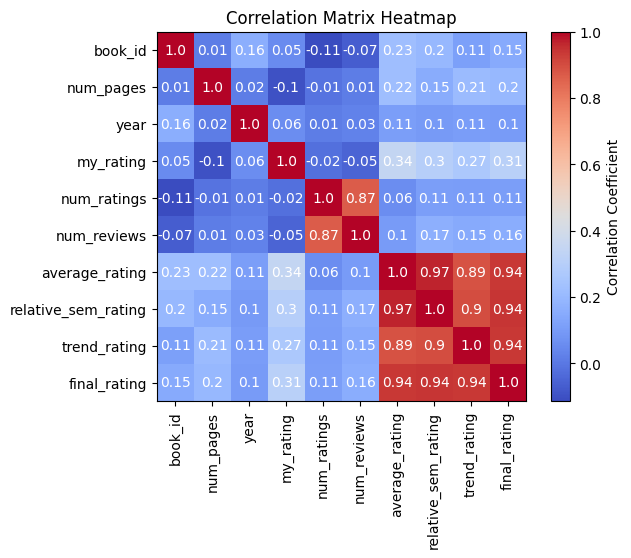

In [42]:
correlation_matrix = df.drop(['genres', 'rating_distribution', 'author', 'book_title', 'book_series', 'publisher'], axis=1).corr()

plt.imshow(correlation_matrix, cmap='coolwarm')  # Adjust 'coolwarm' for preferred colormap

# Add labels and title
plt.colorbar(label='Correlation Coefficient')
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.title('Correlation Matrix Heatmap')

for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        text = plt.text(j, i, round(correlation_matrix.iloc[i, j], 2),
                       ha="center", va="center", color="w")

# Display the plot
plt.show()

In [43]:
# correlation_matrix.sort_values(by='2a', ascending=False)

# Elaborate genres and rating_dist columns

In [44]:
df_exploded = df.explode('genres')
genres_dummies = pd.get_dummies(df_exploded['genres'])

df_exploded = pd.concat([df_exploded, genres_dummies], axis=1)

agg_dict = {col: 'first' for col in df_exploded.columns.difference(['genres']+list(genres_dummies.columns))}
agg_dict.update({col: 'sum' for col in genres_dummies.columns})

df_genres = df_exploded.groupby('book_id', as_index=False).agg(agg_dict)


In [45]:
# drop uncommon genres
mean_genres = pd.Series(genres_dummies.mean(), index=genres_dummies.columns)
for column in df_genres.columns:
    if column in mean_genres.index and mean_genres.loc[column] < mean_genres.mean():
        df_genres = df_genres.drop(column, axis=1)

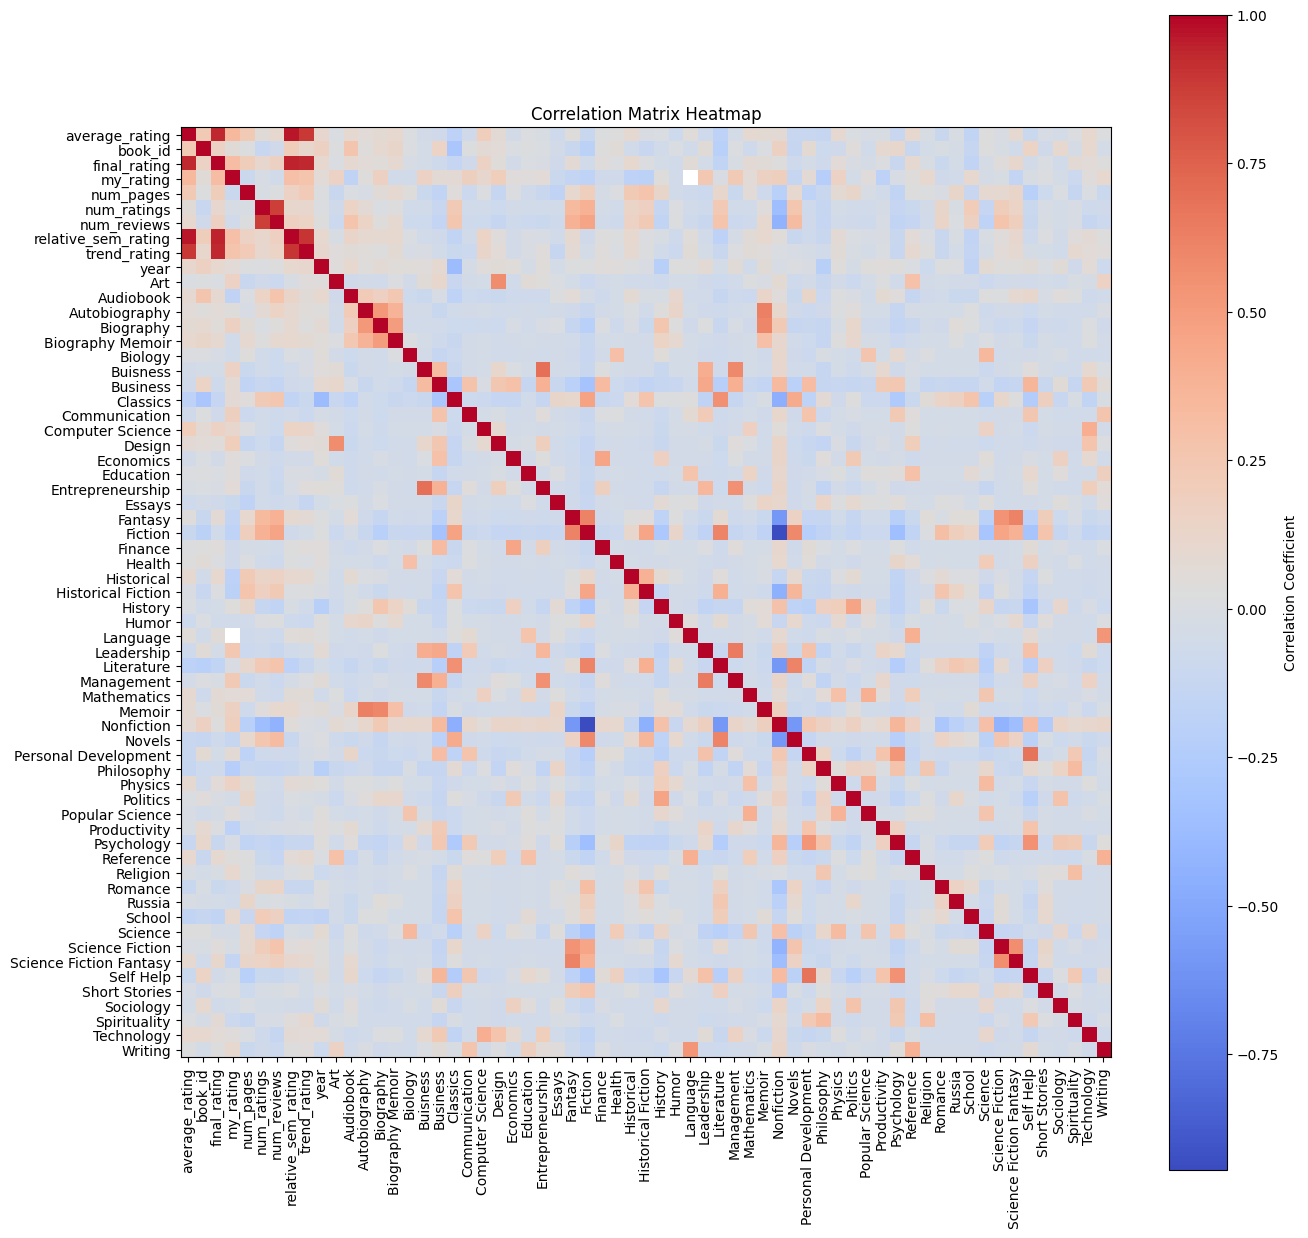

In [46]:
correlation_matrix = df_genres.drop(['rating_distribution', 'author', 'book_title', 'book_series', 'publisher'], axis=1).corr()
plt.figure(figsize=(15,15))
plt.imshow(correlation_matrix, cmap='coolwarm')  # Adjust 'coolwarm' for preferred colormap

# Add labels and title
plt.colorbar(label='Correlation Coefficient')
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.title('Correlation Matrix Heatmap')

# Display the plot
plt.show()

In [47]:
correlation_matrix.sort_values(by='my_rating', ascending=False).head(30)


,average_rating,book_id,final_rating,my_rating,num_pages,num_ratings,num_reviews,relative_sem_rating,trend_rating,year,Art,Audiobook,Autobiography,Biography,Biography Memoir,Biology,Buisness,Business,Classics,Communication,Computer Science,Design,Economics,Education,Entrepreneurship,Essays,Fantasy,Fiction,Finance,Health,Historical,Historical Fiction,History,Humor,Language,Leadership,Literature,Management,Mathematics,Memoir,Nonfiction,Novels,Personal Development,Philosophy,Physics,Politics,Popular Science,Productivity,Psychology,Reference,Religion,Romance,Russia,School,Science,Science Fiction,Science Fiction Fantasy,Self Help,Short Stories,Sociology,Spirituality,Technology,Writing
my_rating,0.344376,0.053262,0.310244,1.000000,-0.098081,-0.019718,-0.050643,0.297710,0.267428,0.058665,0.153427,-0.162988,0.029035,0.158563,-0.049000,-0.049000,0.153427,0.069740,0.071864,0.175425,0.107801,1.891256e-01,0.041844,0.041844,0.059950,-0.099916,-0.141066,-0.171071,-0.069740,-0.069740,-0.184421,-0.190155,0.029035,-0.049000,NaN,0.235051,-0.006585,0.219815,5.994966e-02,0.158563,0.180876,-0.123307,0.070406,-0.229216,0.153427,-0.040483,0.041844,-0.177663,-0.024584,0.031487,0.097428,-0.069740,-0.049000,0.097428,-0.026074,-0.011560,-0.145175,-0.011059,0.005731,-0.040483,-0.087105,0.041844,0.097428
average_rating,1.000000,0.225076,0.936085,0.344376,0.223641,0.056968,0.101463,0.965901,0.889773,0.108103,-0.002334,0.091848,0.059528,0.079103,0.098631,0.007224,-0.043622,-0.068025,-0.177594,-0.068024,0.190433,7.109555e-02,-0.046989,0.005846,-0.015796,-0.073321,0.033436,-0.101546,0.015099,0.027302,0.081537,-0.005649,-0.000145,-0.082025,0.045196,-0.071142,-0.182218,-0.033851,8.535412e-02,0.075501,0.065802,-0.114787,-0.111603,-0.128134,0.084417,0.000088,-0.019321,-0.012765,-0.113794,0.100467,-0.015663,-0.104808,-0.017826,-0.151391,0.026111,-0.007084,0.090728,-0.097961,-0.024817,-0.038989,0.007612,0.097584,0.019408
final_rating,0.936085,0.151008,1.000000,0.310244,0.198566,0.107937,0.156902,0.940916,0.935520,0.102847,0.002924,0.085094,0.060548,0.043405,0.080988,-0.020599,-0.033236,-0.072973,-0.134108,-0.068630,0.150872,4.858525e-02,-0.041847,-0.001052,-0.002765,-0.068595,0.070177,-0.054347,0.038562,0.008276,0.103374,0.005436,-0.035481,-0.052893,0.055338,-0.037722,-0.149344,-0.011262,6.778278e-02,0.053590,0.023543,-0.073153,-0.036769,-0.073910,0.064823,-0.008783,-0.028944,0.006207,-0.101686,0.092606,-0.016337,-0.100406,-0.035845,-0.153633,-0.028365,0.037588,0.113613,-0.044877,-0.002166,-0.055990,0.070345,0.065470,0.025497
relative_sem_rating,0.965901,0.195994,0.940916,0.297710,0.153786,0.111726,0.168589,1.000000,0.898872,0.096513,-0.014896,0.130489,0.087769,0.094533,0.102484,-0.000981,-0.048446,-0.068110,-0.150446,-0.056475,0.142752,4.023305e-02,-0.047970,-0.003334,-0.021432,-0.050361,0.089563,-0.063569,0.021442,0.016610,0.102081,0.007835,-0.012493,-0.072754,0.045574,-0.053910,-0.183537,-0.031492,5.311618e-02,0.103298,0.043140,-0.105738,-0.072960,-0.105482,0.067109,-0.000679,-0.019296,-0.005205,-0.106622,0.063674,0.003983,-0.105024,-0.012509,-0.151714,-0.010846,0.037106,0.110240,-0.072254,0.011035,-0.047410,0.040924,0.065707,0.022791
trend_rating,0.889773,0.112226,0.935520,0.267428,0.210404,0.106252,0.147545,0.898872,1.000000,0.106935,0.037950,0.054056,0.049187,0.026607,0.077042,-0.019046,-0.006914,-0.061619,-0.097372,-0.093865,0.132320,6.144408e-02,-0.043050,-0.003158,0.036743,-0.125289,0.068629,-0.033210,0.035370,-0.002167,0.084333,0.017044,-0.061365,-0.091247,0.056615,-0.035537,-0.104967,0.004981,5.054950e-02,0.036207,0.001854,-0.018824,-0.027533,-0.053901,0.056006,-0.015487,-0.039722,-0.002340,-0.109651,0.081357,0.025126,-0.107891,-0.033544,-0.145999,-0.029654,0.060238,0.092812,-0.031457,-0.036411,-0.060948,0.091043,0.063313,0.041016
Leadership,-0.071142,0.052476,-0.037722,0.235051,-0.093105,-0.072833,-0.103437,-0.053910,-0.035537,0.067404,-0.069969,-0.054759,-0.065249,0.013651,-0.061938,-0.066853,0.407911,0.437537,-0.164158,0.210337,-0.056665,-2.926969e-02

In [48]:
# with pd.option_context('display.max_rows', None, 'display.max_columns', None):
#     display(df.sort_values(by='2a', ascending=False))